In [9]:
# 라이브러리 준비
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 시각화 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 학습 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)


사용 디바이스: cpu


In [ ]:
# 이미지를 Tensor로 변환 후 [0, 1] 정규화
# transforms.ToTensor()    : (H, W, C) uint8 → (C, H, W) float32, 값을 0~1 범위로 변환
# transforms.Normalize()   : 평균 0.1307, 표준편차 0.3081 (MNIST 전체 통계)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)), # 평균, 포준편차
    transforms.Lambda(lambda x: x.view(-1))   # (1, 28, 28) → (784,) 1차원 변환 view(-1) -> 모든 데이터를 하나로 묶기
])

# pytorch 제공하는 MNIST 데이터셋 준비
train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"훈련 샘플 수 : {len(train_dataset):,}")   # 60,000
print(f"테스트 샘플 수: {len(test_dataset):,}")    # 10,000
print(f"샘플 shape   : {train_dataset[0][0].shape}")  # torch.Size([784])
print(f"레이블 종류  : {sorted(set(train_dataset.targets.tolist()))}")  # [0~9]


100.0%
100.0%
100.0%
100.0%

훈련 샘플 수 : 60,000
테스트 샘플 수: 10,000
샘플 shape   : torch.Size([784])
레이블 종류  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


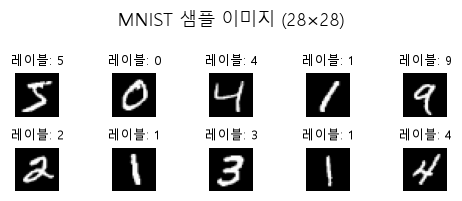

1차원 변환 후 shape: torch.Size([784])
1차원 변환 후 값 범위: [-0.424, 2.821]


In [12]:
# image = train_dataset[0][0].numpy()
# image2 = image.reshape((28),(28))
# print (image.shape, image2.shape)

# plt.figure(figsize=(1,1))
# plt.imshow(image2, cmap='gray')
# plt.axis('off')
# plt.show()

# 샘플 이미지 시각화 (1차원 변환 전 원본 확인)
sample_transform = transforms.Compose([
    transforms.ToTensor(),
])
sample_ds = datasets.MNIST(root="./data", train=True, download=False, transform=sample_transform)

fig, axes = plt.subplots(2, 5, figsize=(5, 2)) # 그리기 화면을 2행 5열로 나누기 -> 각 그리기 영역 : axes
for i, ax in enumerate(axes.flat):
    img, label = sample_ds[i]
    ax.imshow(img.squeeze(), cmap="gray") # 현재 그리기 영역에 이미지 그리기 imshow, squeeze() : (1, 28, 28) => (28, 28)
    ax.set_title(f"레이블: {label}", fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST 샘플 이미지 (28×28)", fontsize=13)
plt.tight_layout()
plt.show()

print("1차원 변환 후 shape:", train_dataset[0][0].shape)   # torch.Size([784])
print("1차원 변환 후 값 범위: [{:.3f}, {:.3f}]".format(
    train_dataset[0][0].min().item(), train_dataset[0][0].max().item()
))


In [13]:
# DataLoader 준비

BATCH_SIZE = 128    # MNIST는 데이터 규모가 크므로 더 큰 배치 사용

# 훈련/검증 분리 (훈련 세트 60,000 → 48,000 훈련 + 12,000 검증)
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_ds, val_ds = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # 시드는 42 고정
)

train_loader = DataLoader(train_ds,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"훈련 {len(train_ds):,}개 ({len(train_loader)} 배치) | "
      f"검증 {len(val_ds):,}개 | 테스트 {len(test_dataset):,}개")

# 배치 확인
X_batch, y_batch = next(iter(train_loader))
print(f"배치 입력 shape: {X_batch.shape}")   # (128, 784)
print(f"배치 레이블 shape: {y_batch.shape}") # (128,)


훈련 48,000개 (375 배치) | 검증 12,000개 | 테스트 10,000개
배치 입력 shape: torch.Size([128, 784])
배치 레이블 shape: torch.Size([128])


In [14]:
# 모델설계

# 784 → 256 → 128 → 64 → 10 (다중 분류)
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)   # 출력: 10개 클래스 로짓(logit)
            # Softmax는 CrossEntropyLoss 내부에 포함 → 별도 추가 불필요
        )

    def forward(self, x):
        return self.net(x)

model = MNISTNet().to(device)
print(model)
print(f"전체 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


MNISTNet(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)
전체 파라미터 수: 242,762


In [16]:
# 훈련 설계 (학습 설계)

EPOCHS = 20     # MNIST는 에폭 수가 적어도 높은 정확도 달성 가능
LR     = 0.001

criterion = nn.CrossEntropyLoss()   # 다중 분류: Softmax + NLLLoss 통합
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) # 10번 스텝마다 학습률 50% 줄이게 설정


In [17]:
# 훈련 실행 (학습 실행)

history      = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0 # 얼리 스탑핑 위해

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Acc':>8}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    # ── 훈련 ──────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)   # y_b: LongTensor (정수 레이블)
        pred = model(X_b)                              # (배치, 10) 로짓
        loss = criterion(pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() # 가중치 업데이트
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── 검증 ──────────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            pred      = model(X_b)
            val_loss += criterion(pred, y_b).item()
            correct  += (pred.argmax(dim=1) == y_b).sum().item()
            total    += y_b.size(0)
    val_loss /= len(val_loader)
    val_acc   = correct / total

    scheduler.step()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:  # 최고 성적 모델 저장 위해
        best_val_acc = val_acc
        torch.save(model.state_dict(), "mnist_best.pt")

    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_acc:>7.2%}")

print(f"\n최고 검증 정확도: {best_val_acc:.2%} → mnist_best.pt 저장")

 Epoch | Train Loss |   Val Loss |  Val Acc
---------------------------------------------
     1 |     0.4113 |     0.1758 |  94.82%
     2 |     0.1726 |     0.1347 |  95.94%
     3 |     0.1302 |     0.1099 |  96.73%
     4 |     0.1072 |     0.1029 |  96.88%
     5 |     0.0954 |     0.0887 |  97.46%
     6 |     0.0838 |     0.0905 |  97.33%
     7 |     0.0760 |     0.0909 |  97.44%
     8 |     0.0702 |     0.0844 |  97.63%
     9 |     0.0638 |     0.0864 |  97.67%
    10 |     0.0619 |     0.0822 |  97.75%
    11 |     0.0405 |     0.0738 |  98.01%
    12 |     0.0363 |     0.0742 |  97.92%
    13 |     0.0338 |     0.0765 |  98.03%
    14 |     0.0340 |     0.0751 |  97.97%
    15 |     0.0306 |     0.0767 |  97.75%
    16 |     0.0286 |     0.0821 |  97.84%
    17 |     0.0316 |     0.0803 |  97.99%
    18 |     0.0304 |     0.0785 |  97.92%
    19 |     0.0279 |     0.0790 |  97.97%
    20 |     0.0268 |     0.0818 |  97.92%

최고 검증 정확도: 98.03% → mnist_best.pt 저장


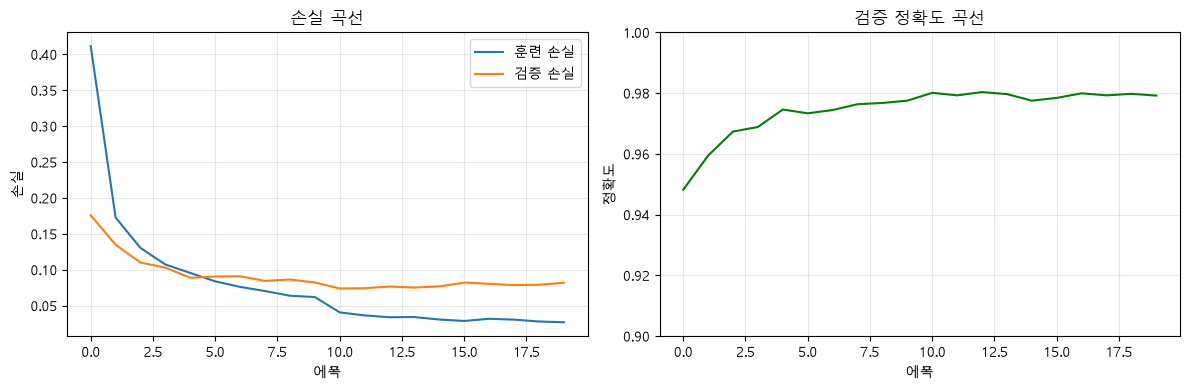

In [18]:
# 훈련 과정 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="훈련 손실")
axes[0].plot(history["val_loss"],   label="검증 손실")
axes[0].set_title("손실 곡선")
axes[0].set_xlabel("에폭")
axes[0].set_ylabel("손실")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_acc"], color="green")
axes[1].set_title("검증 정확도 곡선")
axes[1].set_xlabel("에폭")
axes[1].set_ylabel("정확도")
axes[1].set_ylim(0.9, 1.0)   # 97% 이상을 기대하므로 축 범위를 좁혀 변화 확인
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mnist_training_curve.png", dpi=100, bbox_inches="tight")
plt.show()


In [19]:
# 최종 테스트

# 최고 모델 불러오기
model.load_state_dict(torch.load("mnist_best.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        pred = model(X_b.to(device))
        all_preds.extend(pred.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_b.numpy())

print("=== 테스트 세트 평가 결과 ===")
print(classification_report(all_labels, all_preds,
                             target_names=[str(i) for i in range(10)]))


=== 테스트 세트 평가 결과 ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



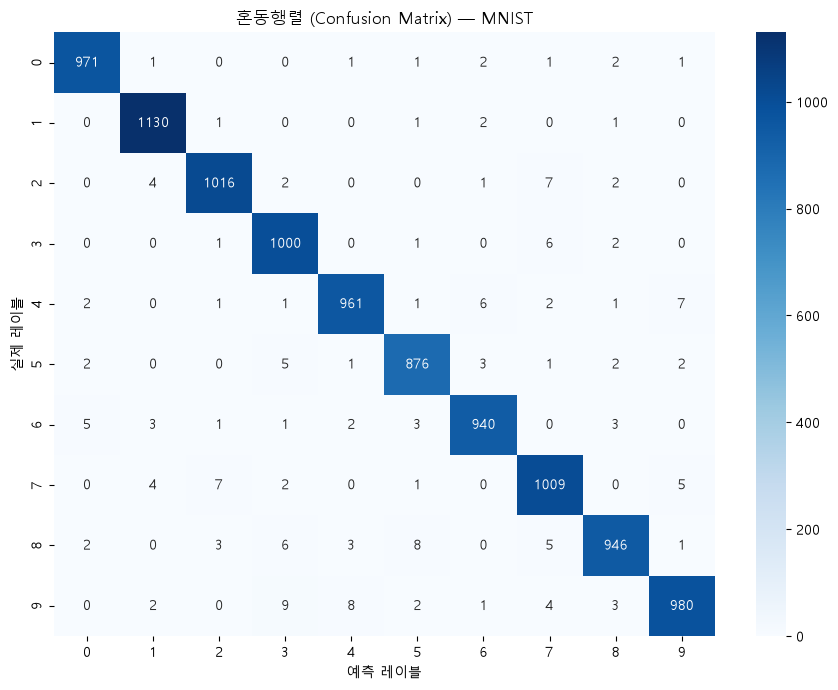

In [20]:
# 혼동행렬 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("혼동행렬 (Confusion Matrix) — MNIST")
plt.xlabel("예측 레이블")
plt.ylabel("실제 레이블")
plt.tight_layout()
plt.savefig("mnist_confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()


오분류 샘플 수: 171 / 10000


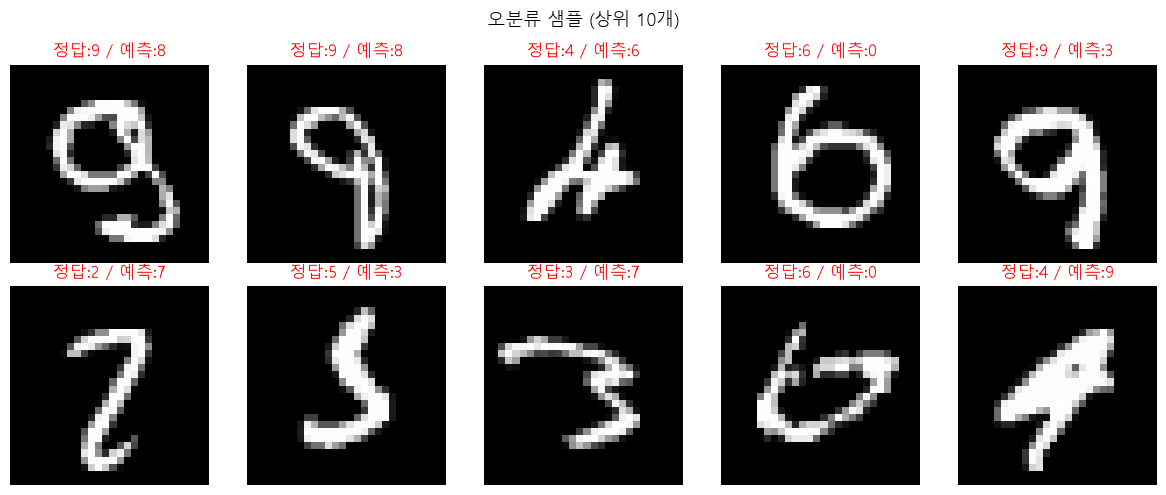

In [21]:
# 오분류 샘플 시각화 (원본 이미지 복원)
raw_test_ds = datasets.MNIST(root="./data", train=False, download=False,
                              transform=transforms.ToTensor())

errors = [(i, p, l) for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
print(f"오분류 샘플 수: {len(errors)} / {len(all_labels)}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, (idx, pred, label) in zip(axes.flat, errors[:10]):
    img, _ = raw_test_ds[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"정답:{label} / 예측:{pred}", color="red")
    ax.axis("off")
plt.suptitle("오분류 샘플 (상위 10개)", fontsize=13)
plt.tight_layout()
plt.savefig("mnist_errors.png", dpi=100, bbox_inches="tight")
plt.show()


In [22]:
# 최종 모델 저장

torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc": best_val_acc,
    "history":     history,
}, "mnist_checkpoint.pt")

print("저장 완료:")
print("  - mnist_best.pt        (추론용 — state_dict만)")
print("  - mnist_checkpoint.pt  (재훈련용 — 전체 상태)")


저장 완료:
  - mnist_best.pt        (추론용 — state_dict만)
  - mnist_checkpoint.pt  (재훈련용 — 전체 상태)
